## Poster Timeseries Plots

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from utide import solve, reconstruct 
import scipy
import matplotlib.gridspec as gridspec

convert wr03,4,7 from utc to local

**MET DATA**

In [65]:
# Handle NOAA met data

# define met filepath and read file and COMPILE MET DATA
nov25met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointNovMet.csv"
dec25met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointDecMet.csv"
jan26met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointJanMet.csv"

nov25met_df = pd.read_csv(nov25met_file)
dec25met_df = pd.read_csv(dec25met_file)
jan26met_df = pd.read_csv(jan26met_file)

met_df = pd.concat([nov25met_df, dec25met_df, jan26met_df], ignore_index=True) # LST time and metric
met_df["Datetime"] = pd.to_datetime(met_df["Date"].astype(str) + " " + met_df["Time (LST)"].astype(str), errors="coerce")
met_df = met_df.set_index("Datetime").sort_index()

# Convert to numeric and to Pa
met_df["Baro (Pa)"] = pd.to_numeric(met_df["Baro (mb)"], errors='coerce') * 100

# Create 5-minute baseline using Pa
met_df_5min = met_df['Baro (Pa)'].resample('5min').interpolate(method='linear')


def itp_noaa_metdata(met_5min_series, sensor_dt_array): 
    """
    Interpolate NOAA atm pressure from 5-min baseline to sensor timestamps

    Parameters:
    - NOAA meteorological dataframe interpolated to 5-min intervals
    - sensor datetime array

    Returns:
    - array of pressure values interpolated at sensor timestamps

    """

    sensor_dt = pd.DatetimeIndex(sensor_dt_array)
    all_times = met_5min_series.index.union(sensor_dt).unique().sort_values()
    combo = met_5min_series.reindex(all_times).interpolate(method="linear")
    
    itp_pressure = combo.loc[sensor_dt]

    return itp_pressure

**HANDLE DENSITY + FTH2O**

In [68]:
# Take ftH2O array and create TWL [m] 

def density(T, S):
    """
    input: temperature array in deg celsius, constant salinity value in PSU
    output: density in kg/m^3
    """
    rho_fw = 1000 * (1 - ((T + 288.9414)/(508929.2*(T + 68.12963))) * (T - 3.9863)**2)
    rho_ew = rho_fw + (0.824 * S)
    return rho_ew

def ftH2O_to_Pa(pressure_ftH2O, temperature, salinity):
    """
    Convert pressure from ftH2O to Pascals, accounting for temperature and salinity.
    
    INPUTS
    pressure_ftH2O : (array) pressure readings in feet of water (ftH2O)
    temperature : (array) temperature readings in degrees Celsius
    salinity : constant salinity value in PSU
    
    OUTPUTS
    pressure_Pa : array-like
        Pressure in Pascals
    """
    # Constants
    g = 9.81  # gravitational acceleration (m/s²)
    ft_to_m = 0.3048  # feet to meters conversion
    
    # Calculate density based on temperature and salinity
    rho = density(temperature, salinity)
    
    # Convert ftH2O to meters of water, then to Pascals
    # P = ρ * g * h
    pressure_Pa = rho * g * (pressure_ftH2O * ft_to_m)
    
    return pressure_Pa

**TP**

In [71]:
### NOAA nov+dec+jan

TPnov_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPnov.csv"
TPdec_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPdec.csv"
TPjan_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPjan.csv"

TPnov_df = pd.read_csv(TPnov_file)
TPdec_df = pd.read_csv(TPdec_file)
TPjan_df = pd.read_csv(TPjan_file)

TP_df = pd.concat([TPnov_df, TPdec_df, TPjan_df], ignore_index=True) # LST time and metric

TP_df['DateTime'] = pd.to_datetime(TP_df['Date'] + ' ' + TP_df['Time (LST/LDT)'])
TP_df['Verified (m)'] = pd.to_numeric(TP_df['Verified (m)'], errors='coerce')

TP_dt = TP_df["DateTime"]
TP_twl = TP_df["Verified (m)"]

TP_df.head()

,Date,Time (LST/LDT),Predicted (m),Preliminary (m),Verified (m),DateTime
0,2025/11/06,00:00,2.109,-,2.478,2025-11-06 00:00:00
1,2025/11/06,00:06,2.147,-,2.513,2025-11-06 00:06:00
2,2025/11/06,00:12,2.182,-,2.549,2025-11-06 00:12:00
3,2025/11/06,00:18,2.215,-,2.585,2025-11-06 00:18:00
4,2025/11/06,00:24,2.244,-,2.616,2025-11-06 00:24:00


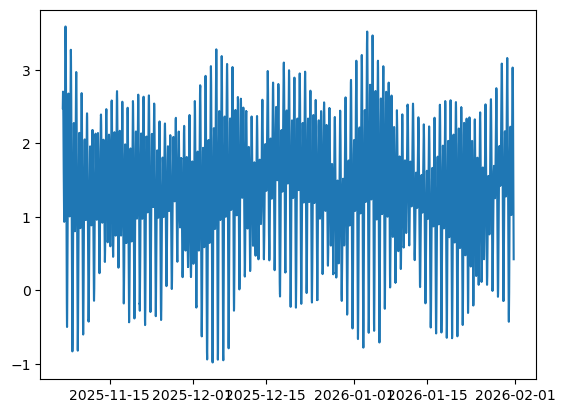

In [73]:
plt.plot(TP_dt, TP_twl)

**WR01**

In [131]:
wr01_novdec_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/BendiksenNovDec.xlsx"
wr01_janfeb_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/BendiksenJanFeb.xlsx"
wr01_marapr_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/BendiksenMarApr.xlsx"

wr01_novdec_df = pd.read_excel(wr01_novdec_file, skiprows=1)
wr01_janfeb_df = pd.read_excel(wr01_janfeb_file, skiprows=1,)
wr01_marapr_df = pd.read_excel(wr01_marapr_file, skiprows=1)
wr01_df = pd.concat([wr01_novdec_df, wr01_janfeb_df, wr01_marapr_df], ignore_index=True)

# data cleaning
wr01_df["SWE NAVD88 (m)"] = (wr01_df["Level/Stage (ft)"] * 0.3048) - 0.427  # in m NAVD88
wr01_df['Date&Time'] = pd.to_datetime(wr01_df["Date&Time"], format="%m/%d/%Y %I:%M:%S %p")
wr01_df = wr01_df.sort_values('Date&Time').reset_index(drop=True)

wr01_df = wr01_df.iloc[100:].reset_index(drop=True)
wr01_df = wr01_df.set_index('Date&Time')
wr01_df = wr01_df.asfreq('5min')
wr01_df.loc['2025-12-05 08:55:00':'2025-12-06 15:10:00', 'SWE NAVD88 (m)'] = np.nan

wr01_dt = wr01_df.index
wr01_twl = wr01_df["SWE NAVD88 (m)"]

wr01_df.head()

,Location,Data Sent,isDeleted,Level/Stage (ft),L1,L2,L3,SWE NAVD88 (m)
Date&Time,,,,,,,,
2025-11-08 01:50:00,Bendiksen Landing,False,False,6.53,10.49,10.50,10.50,1.563344
2025-11-08 01:55:00,Bendiksen Landing,False,False,6.68,10.35,10.34,10.33,1.609064
2025-11-08 02:00:00,Bendiksen Landing,False,False,6.83,10.18,10.18,10.20,1.654784
2025-11-08 02:05:00,Bendiksen Landing,True,False,6.99,10.04,10.04,10.01,1.703552
2025-11-08 02:10:00,Bendiksen Landing,False,False,7.12,9.91,9.90,9.89,1.743176


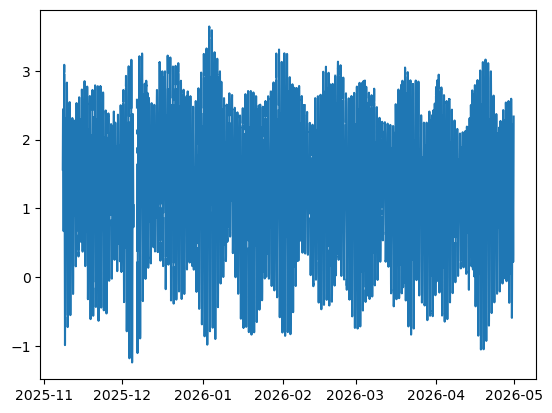

In [132]:
plt.plot(wr01_dt, wr01_twl)

**WR02** 

In [136]:
wr02_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/Raymond_nov7tojan31.xlsx"
wr02_df = pd.read_excel(wr02_file, skiprows=1)

# data cleaning
wr02_df["SWE NAVD88 (m)"] = (wr02_df["Level/Stage (ft)"] * 0.3048) - 0.427
wr02_df['Date&Time'] = pd.to_datetime(wr02_df["Date&Time"], format="%m/%d/%Y %I:%M:%S %p")
wr02_df = wr02_df.sort_values('Date&Time').reset_index(drop=True)

wr02_df = wr02_df.iloc[100:].reset_index(drop=True)
wr02_df = wr02_df.set_index('Date&Time')
wr02_df = wr02_df.asfreq('5min')
wr02_df.loc['2025-12-05 08:55:00':'2025-12-06 15:10:00', 'SWE NAVD88 (m)'] = np.nan

wr02_dt = wr02_df.index
wr02_twl = wr02_df["SWE NAVD88 (m)"]

wr02_df.head()

,Location,Data Sent,isDeleted,Level/Stage (ft),L1,L2,L3,L4,L5,SWE NAVD88 (m)
Date&Time,,,,,,,,,,
2025-11-07 21:00:00,Raymond,False,False,0.30,19.70,19.70,19.70,19.71,19.70,-0.335560
2025-11-07 21:05:00,Raymond,False,False,0.34,19.66,19.66,19.66,19.66,19.67,-0.323368
2025-11-07 21:10:00,Raymond,False,False,0.44,19.56,19.58,19.56,19.56,19.56,-0.292888
2025-11-07 21:15:00,Raymond,False,False,0.54,19.46,19.47,19.46,19.46,19.46,-0.262408
2025-11-07 21:20:00,Raymond,False,False,0.66,19.34,19.35,19.35,19.34,19.34,-0.225832


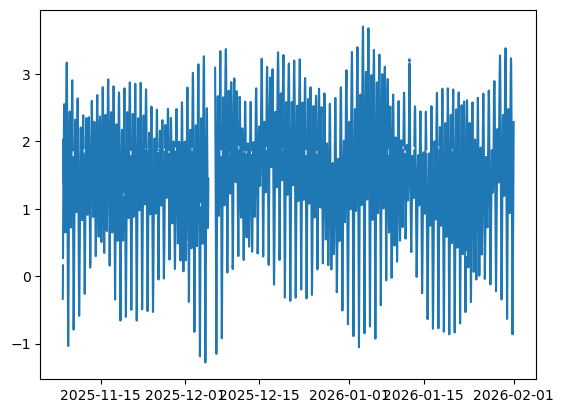

In [138]:
plt.plot(wr02_dt, wr02_twl)

**WR03**

In [141]:
wr03_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/WR03_260111133519_FS029.CSV"
wr03_df = pd.read_csv(wr03_file, encoding='latin-1', skiprows=51, skipfooter=1, engine='python')

# data cleaning
wr03_df = wr03_df.iloc[24:19083].reset_index(drop=True)
wr03_df.loc[11028:11036, 'Pressure[ftH2O]'] = np.nan
wr03_df['Pressure[ftH2O]'] = wr03_df['Pressure[ftH2O]'].interpolate(method='linear')

wr03_df['Date/time'] = pd.to_datetime(wr03_df['Date/time'])
wr03_df['DateTime_PST'] = wr03_df['Date/time'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

g = 9.81 # m/s^2
salinity = 0.5 # PSU approx based on CTD data
wr03_df["Rho[kg/m^3]"] = density(wr03_df["Temperature[°C]"], salinity)

wr03_absp_Pa = ftH2O_to_Pa(wr03_df["Pressure[ftH2O]"], wr03_df["Temperature[°C]"], salinity)
wr03_df["AbsPressure[Pa]"] = wr03_absp_Pa

wr03_itp_metp = itp_noaa_metdata(met_df_5min, wr03_df["Date/time"])
wr03_df["MetPressure[Pa]"] = wr03_itp_metp.values

wr03_df["TWL[m]"] = (wr03_df["AbsPressure[Pa]"] - wr03_df["MetPressure[Pa]"]) / (wr03_df["Rho[kg/m^3]"] * g)
wr03_df["TWL[m]"] = np.where(wr03_df["TWL[m]"] < 0, np.nan, wr03_df["TWL[m]"])

wr03_df["TWLNAVD88[m]"] = wr03_df["TWL[m]"] - 1.108

wr03_dt = wr03_df["DateTime_PST"]
wr03_twl = wr03_df["TWLNAVD88[m]"]

wr03_df.head()

,Date/time,Pressure[ftH2O],Temperature[°C],DateTime_PST,Rho[kg/m^3],AbsPressure[Pa],MetPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025-11-06 16:00:00,40.17334,10.657,2025-11-06 08:00:00,1000.079515,120131.373308,100760.000000,1.974499,0.866499
1,2025-11-06 16:05:00,40.32070,10.633,2025-11-06 08:05:00,1000.081829,120572.306694,100758.333333,2.019608,0.911608
2,2025-11-06 16:10:00,40.48146,10.633,2025-11-06 08:10:00,1000.081829,121053.032574,100756.666667,2.068777,0.960777
3,2025-11-06 16:15:00,40.62883,10.623,2025-11-06 08:15:00,1000.082791,121493.834760,100755.000000,2.113875,1.005875
4,2025-11-06 16:20:00,40.79916,10.617,2025-11-06 08:20:00,1000.083367,122003.248947,100753.333333,2.165968,1.057968


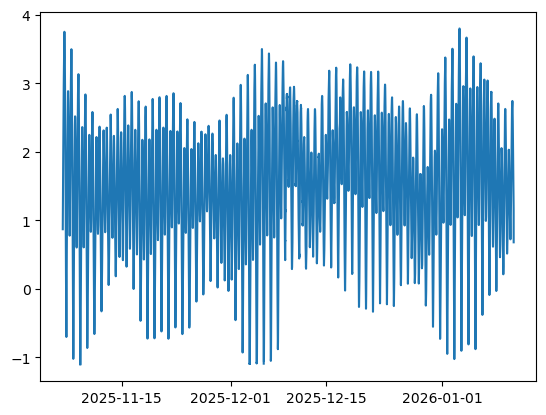

In [143]:
plt.plot(wr03_dt, wr03_twl)

**WR04**

In [146]:
# reading diver WR04_260111133906_FS064.CSV

wr04_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/WR04_260111133906_FS064.CSV"
wr04_df = pd.read_csv(wr04_file, encoding='latin-1', skiprows=51, skipfooter=1, engine='python')

# data cleaning
wr04_df = wr04_df.iloc[24:19083].reset_index(drop=True)
wr04_df.loc[11028:11036, 'Pressure[ftH2O]'] = np.nan
wr04_df['Pressure[ftH2O]'] = wr04_df['Pressure[ftH2O]'].interpolate(method='linear')
wr04_df['Date/time'] = pd.to_datetime(wr04_df['Date/time'])
wr04_df['DateTime_PST'] = wr04_df['Date/time'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

g = 9.81 # m/s^2
salinity = 0 # PSU approx based on CTD data
wr04_df["Rho[kg/m^3]"] = density(wr04_df["Temperature[°C]"], salinity)

wr04_absp_Pa = ftH2O_to_Pa(wr04_df["Pressure[ftH2O]"], wr04_df["Temperature[°C]"], salinity)
wr04_df["AbsPressure[Pa]"] = wr04_absp_Pa

wr04_itp_metp = itp_noaa_metdata(met_df_5min, wr04_df["Date/time"])
wr04_df["MetPressure[Pa]"] = wr04_itp_metp.values

wr04_df["TWL[m]"] = (wr04_df["AbsPressure[Pa]"] - wr04_df["MetPressure[Pa]"]) / (wr04_df["Rho[kg/m^3]"] * g)
wr04_df["TWL[m]"] = np.where(wr04_df["TWL[m]"] < 0, np.nan, wr04_df["TWL[m]"])

wr04_df["TWLNAVD88[m]"] = wr04_df["TWL[m]"] - 1.108

wr04_dt = wr04_df["DateTime_PST"]
wr04_twl = wr04_df["TWLNAVD88[m]"]

wr04_df.head()

,Date/time,Pressure[ftH2O],Temperature[°C],DateTime_PST,Rho[kg/m^3],AbsPressure[Pa],MetPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025-11-06 16:00:00,40.11975,10.667,2025-11-06 08:00:00,999.666548,119921.581646,100760.000000,1.953922,0.845922
1,2025-11-06 16:05:00,40.23841,10.673,2025-11-06 08:05:00,999.665968,120276.197338,100758.333333,1.990253,0.882253
2,2025-11-06 16:10:00,40.38577,10.650,2025-11-06 08:10:00,999.668190,120716.937917,100756.666667,2.035362,0.927362
3,2025-11-06 16:15:00,40.55610,10.673,2025-11-06 08:15:00,999.665968,121225.801090,100755.000000,2.087425,0.979425
4,2025-11-06 16:20:00,40.74174,10.673,2025-11-06 08:20:00,999.665968,121780.695612,100753.333333,2.144178,1.036178


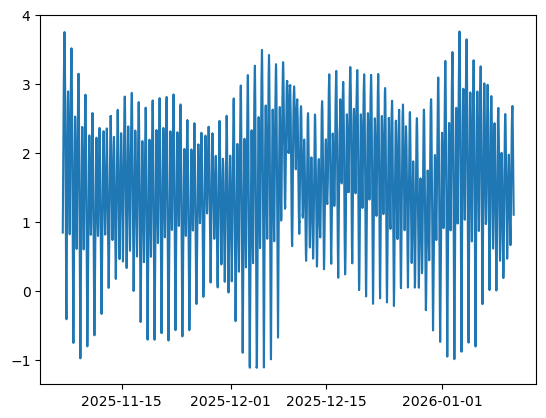

In [148]:
plt.plot(wr04_dt, wr04_twl)

**WR06**

In [151]:
# InSitu632743brackish_2026-01-11_13-47-47-563.csv

wr06is_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/InSitu632743brackish_2026-01-11_13-47-47-563.csv"
wr06is_df = pd.read_csv(wr06is_file, skiprows=70)

wr06is_df['datetime'] = pd.to_datetime(wr06is_df['Date and Time'].str.strip(" '"), format='%m/%d/%Y %I:%M:%S %p')

# Create Time shift column - subtract 16 hours
wr06is_df['Time shift'] = wr06is_df['datetime'] - pd.Timedelta(hours=15)

wr06is_df.columns = wr06is_df.columns.str.rstrip()

salinity = 0 # PSU approx based on CTD data
wr06is_df["Temperature (C)"] = (wr06is_df["Temperature (F)"] - 32)*(5/9)
wr06is_df["Rho[kg/m^3]"] = density(wr06is_df["Temperature (C)"], salinity)

g = 9.81

wr06is_itp_metp = itp_noaa_metdata(met_df_5min, wr06is_df["datetime"])
wr06is_df["MetPressure[Pa]"] = wr06is_itp_metp.values

wr06is_df["Press_Pa"] = wr06is_df["Pressure (PSI)"] * 6894.76 # to convert to Pa

wr06is_df["TWL[m]"] = (wr06is_df["Press_Pa"] - wr06is_df["MetPressure[Pa]"]) / (wr06is_df["Rho[kg/m^3]"] * g)
wr06is_df["TWL[m]"] = np.where(wr06is_df["TWL[m]"] < 0, np.nan, wr06is_df["TWL[m]"])

wr06is_df["TWLNAVD88[m]"] = wr06is_df["TWL[m]"] - 1.091 # meters THIS IS AN ESTIMATE

wr06is_dt = wr06is_df["Time shift"]
wr06is_twl= wr06is_df["TWLNAVD88[m]"]

wr06is_dt_trim = wr06is_dt.iloc[274:8287]
wr06is_twl_trim = wr06is_twl.iloc[274:8287] # chagne back to 275

wr06is_df.head()

,Date and Time,Seconds,Temperature (F),Pressure (PSI),Depth (ft),Unnamed: 5,datetime,Time shift,Temperature (C),Rho[kg/m^3],MetPressure[Pa],Press_Pa,TWL[m],TWLNAVD88[m]
0,12/14/2025 9:00:00 AM,0.000,73.871,14.676,33.451,NaN,2025-12-14 09:00:00,2025-12-13 18:00:00,23.261667,997.506093,101560.000000,101187.49776,NaN,NaN
1,12/14/2025 9:05:00 AM,300.001,73.958,14.675,33.448,NaN,2025-12-14 09:05:00,2025-12-13 18:05:00,23.310000,997.494507,101576.666667,101180.60300,NaN,NaN
2,12/14/2025 9:10:00 AM,600.001,73.871,14.673,33.445,NaN,2025-12-14 09:10:00,2025-12-13 18:10:00,23.261667,997.506093,101593.333333,101166.81348,NaN,NaN
3,12/14/2025 9:15:00 AM,900.001,73.958,14.675,33.448,NaN,2025-12-14 09:15:00,2025-12-13 18:15:00,23.310000,997.494507,101610.000000,101180.60300,NaN,NaN
4,12/14/2025 9:20:00 AM,1200.001,73.783,14.673,33.444,NaN,2025-12-14 09:20:00,2025-12-13 18:20:00,23.212778,997.517788,101626.666667,101166.81348,NaN,NaN


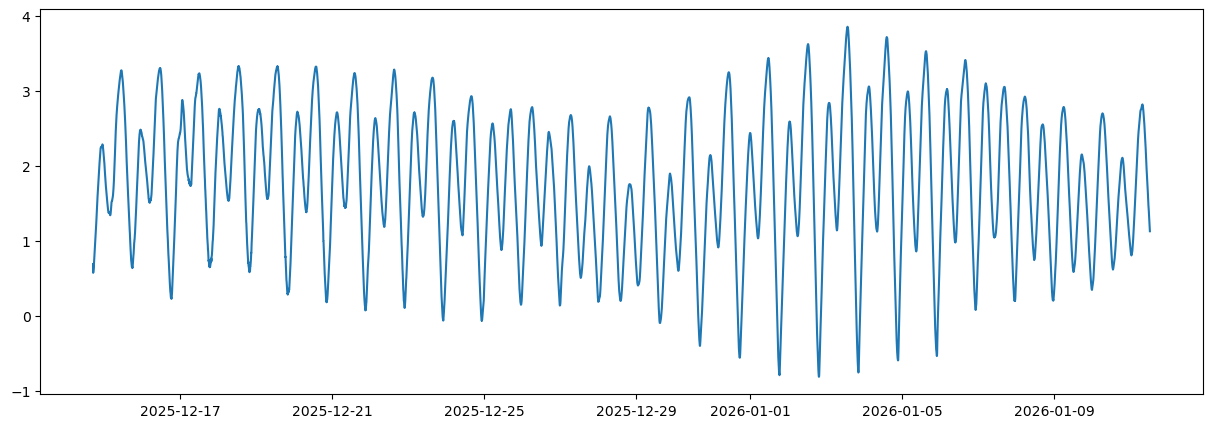

In [153]:
# wr06is_df_trim.plot(x=index, y='TWLNAVD88[m]')
plt.figure(figsize=(15, 5))
plt.plot(wr06is_dt_trim, wr06is_twl_trim)

In [155]:
# CTD 11/6 - 12/15

wr06ctd_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/Copy of CTD_WR06_12.14retrieval.txt"
wr06ctd_df = pd.read_csv(wr06ctd_file, sep=',', skiprows=[0, 2], header=0)

# data cleaning
wr06ctd_df.columns = wr06ctd_df.columns.str.strip()
wr06ctd_df = wr06ctd_df[~wr06ctd_df['Date'].str.contains('-', na=False)]
wr06ctd_df['DateTime'] = pd.to_datetime(wr06ctd_df['Date'] + ' ' + wr06ctd_df['Time'])

# Convert UTC to PST (UTC-8) and remove timezone info
wr06ctd_df['DateTime_PST'] = wr06ctd_df['DateTime'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

wr06ctd_df = wr06ctd_df.reset_index(drop=True)
wr06ctd_df["Press"] = pd.to_numeric(wr06ctd_df["Press"], errors='coerce')
wr06ctd_df = wr06ctd_df.reset_index(drop=True)
wr06ctd_df["Press_Pa"] = wr06ctd_df["Press"] * 6894.76

wr06ctd_df["Temp"] = pd.to_numeric(wr06ctd_df["Temp"], errors='coerce')

salinity = 0 # PSU approx based on CTD data
wr06ctd_df["Rho[kg/m^3]"] = density(wr06ctd_df["Temp"], salinity)
g = 9.81

wr06ctd_itp_metp = itp_noaa_metdata(met_df_5min, wr06ctd_df["DateTime_PST"])
wr06ctd_df["MetPressure[Pa]"] = wr06ctd_itp_metp.values
wr06ctd_df["TWL[m]"] = (wr06ctd_df["Press_Pa"] - wr06ctd_df["MetPressure[Pa]"]) / (wr06ctd_df["Rho[kg/m^3]"] * g)
wr06ctd_df["TWL[m]"] = np.where(wr06ctd_df["TWL[m]"] < 0, np.nan, wr06ctd_df["TWL[m]"])
wr06ctd_df["TWLNAVD88[m]"] = wr06ctd_df["TWL[m]"] - 0.238  # meters

wr06ctd_dt = wr06ctd_df["DateTime_PST"]
wr06ctd_twl= wr06ctd_df["TWLNAVD88[m]"]

wr06ctd_dt_trim = wr06ctd_dt.iloc[20:11068] 
wr06ctd_twl_trim = wr06ctd_twl.iloc[20:11068] - 0.75 # after overlaying wr04 to fix it

wr06ctd_df.tail()

,Date,Time,Temp,SpCond,Sal,Press,Depth,Battery,DateTime,DateTime_PST,Press_Pa,Rho[kg/m^3],MetPressure[Pa],TWL[m],TWLNAVD88[m]
11124,2025/12/15,05:00:08,21.77,0.003,0.00,14.636,-0.056,6.6,2025-12-15 05:00:08,2025-12-14 21:00:08,100911.70736,997.852238,101344.166667,NaN,NaN
11125,2025/12/15,05:05:08,21.63,0.003,0.00,14.632,-0.059,6.6,2025-12-15 05:05:08,2025-12-14 21:05:08,100884.12832,997.883578,101352.500000,NaN,NaN
11126,2025/12/15,05:10:08,21.47,0.003,0.00,14.632,-0.058,6.6,2025-12-15 05:10:08,2025-12-14 21:10:08,100884.12832,997.919150,101360.833333,NaN,NaN
11127,2025/12/15,05:15:08,21.43,0.003,0.00,14.637,-0.055,6.6,2025-12-15 05:15:08,2025-12-14 21:15:08,100918.60212,997.928002,101369.166667,NaN,NaN
11128,2025/12/15,05:20:08,21.40,0.002,0.00,14.644,-0.051,6.7,2025-12-15 05:20:08,2025-12-14 21:20:08,100966.86544,997.934631,101377.500000,NaN,NaN


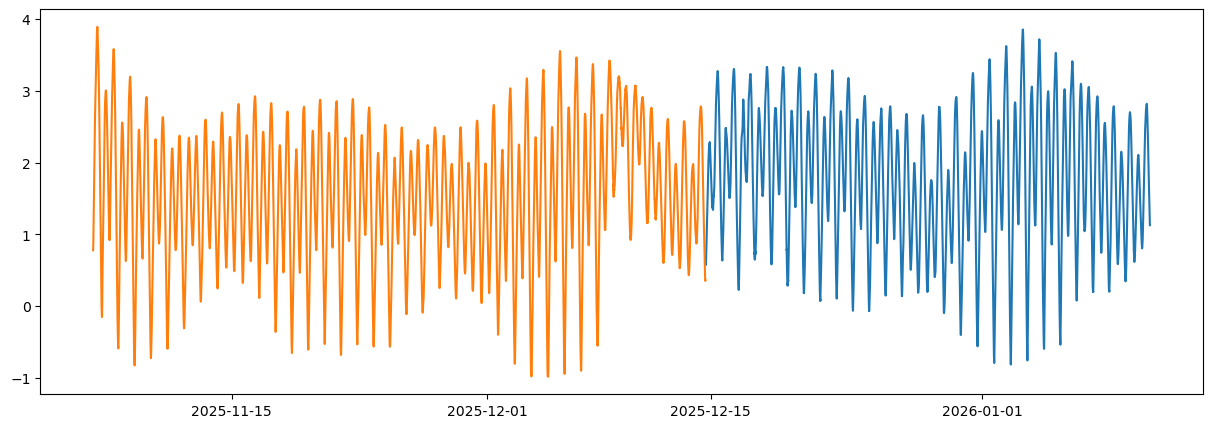

In [157]:
plt.figure(figsize=(15, 5))
# plt.plot(wr04_dt, wr04_twl, color="black")
plt.plot(wr06is_dt_trim, wr06is_twl_trim)
plt.plot(wr06ctd_dt_trim, wr06ctd_twl_trim)


**WR07**

In [160]:
wr07ctd_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/WR07_CTD.txt"
wr07ctd_df = pd.read_csv(wr07ctd_file, sep=',', skiprows=[0, 2], header=0)

# data cleaning
wr07ctd_df.columns = wr07ctd_df.columns.str.strip()
wr07ctd_df = wr07ctd_df[~wr07ctd_df['Date'].str.contains('-', na=False)]
wr07ctd_df['DateTime'] = pd.to_datetime(wr07ctd_df['Date'] + ' ' + wr07ctd_df['Time'])
wr07ctd_df = wr07ctd_df.reset_index(drop=True)
wr07ctd_df["Press"] = pd.to_numeric(wr07ctd_df["Press"], errors='coerce')
wr07ctd_df = wr07ctd_df.iloc[27:13910]
wr07ctd_df = wr07ctd_df.reset_index(drop=True)
wr07ctd_df["Press_Pa"] = wr07ctd_df["Press"] * 6894.76

wr07ctd_df['DateTime'] = pd.to_datetime(wr07ctd_df['DateTime'])
wr07ctd_df['DateTime_PST'] = wr07ctd_df['DateTime'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

wr07ctd_df["Temp"] = pd.to_numeric(wr07ctd_df["Temp"], errors='coerce')

salinity = 0 # PSU approx based on CTD data
wr07ctd_df["Rho[kg/m^3]"] = density(wr07ctd_df["Temp"], salinity)

g = 9.81

wr07ctd_itp_metp = itp_noaa_metdata(met_df_5min, wr07ctd_df["DateTime"])
wr07ctd_df["MetPressure[Pa]"] = wr07ctd_itp_metp.values

wr07ctd_df["TWL[m]"] = (wr07ctd_df["Press_Pa"] - wr07ctd_df["MetPressure[Pa]"]) / (wr07ctd_df["Rho[kg/m^3]"] * g)
wr07ctd_df["TWL[m]"] = np.where(wr07ctd_df["TWL[m]"] < 0, np.nan, wr07ctd_df["TWL[m]"])

wr07ctd_df["TWLNAVD88[m]"] = wr07ctd_df["TWL[m]"] + 0.124 # meters

wr07_dt = wr07ctd_df["DateTime_PST"]
wr07_twl= wr07ctd_df["TWLNAVD88[m]"]

wr07_dt_trim = wr07_dt[:13850]
wr07_twl_trim = wr07_twl[:13850]

wr07ctd_df.head()

,Date,Time,Temp,SpCond,TDS,Sal,Press,Depth,Battery,DateTime,Press_Pa,DateTime_PST,Rho[kg/m^3],MetPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025/11/25,19:15:08,7.68,0.077,0.050,0.04,16.462,1.238,6.4,2025-11-25 19:15:08,113501.53912,2025-11-25 11:15:08,999.895108,101795.833333,1.193367,1.317367
1,2025/11/25,19:20:08,7.67,0.077,0.050,0.04,16.515,1.275,6.4,2025-11-25 19:20:08,113866.96140,2025-11-25 11:20:08,999.895665,101797.500000,1.230451,1.354451
2,2025/11/25,19:25:08,7.67,0.078,0.050,0.04,16.569,1.313,6.4,2025-11-25 19:25:08,114239.27844,2025-11-25 11:25:08,999.895665,101799.166667,1.268237,1.392237
3,2025/11/25,19:30:08,7.67,0.077,0.050,0.04,16.626,1.353,6.4,2025-11-25 19:30:08,114632.27976,2025-11-25 11:30:08,999.895665,101800.000000,1.308218,1.432218
4,2025/11/25,19:35:08,7.67,0.076,0.049,0.04,16.674,1.387,6.4,2025-11-25 19:35:08,114963.22824,2025-11-25 11:35:08,999.895665,101800.000000,1.341957,1.465957


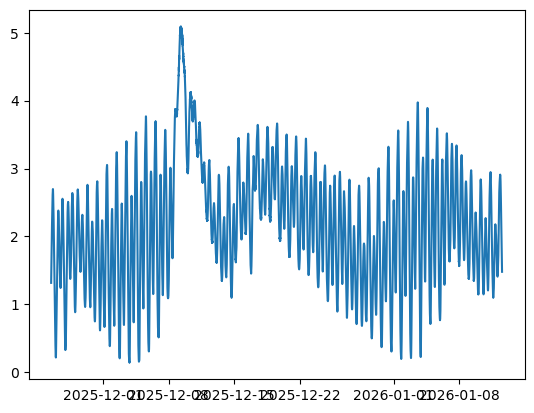

In [162]:
plt.plot(wr07_dt_trim, wr07_twl_trim)

**WR08**

In [165]:
# CTD2004_WR08_012826.txt

wr08_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/CTD2004_WR08_012826.txt"
wr08_df = pd.read_csv(wr08_file, sep=',', skiprows=[0, 2], header=0)

# data cleaning
wr08_df.columns = wr08_df.columns.str.strip()
wr08_df = wr08_df[~wr08_df['Date'].str.contains('-', na=False)]
wr08_df['DateTime'] = pd.to_datetime(wr08_df['Date'] + ' ' + wr08_df['Time'])
wr08_df = wr08_df.reset_index(drop=True)
wr08_df["Press"] = pd.to_numeric(wr08_df["Press"], errors='coerce')
# wr06ctd_df = wr06ctd_df.iloc[27:13910] WHAT ABOUT THIS
wr08_df = wr08_df.reset_index(drop=True)
wr08_df["Press_Pa"] = wr08_df["Press"] * 6894.76

wr08_df['DateTime'] = pd.to_datetime(wr08_df['DateTime'])
wr08_df['DateTime_PST'] = wr08_df['DateTime'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)


wr08_df["Temp"] = pd.to_numeric(wr08_df["Temp"], errors='coerce')

salinity = 0 # PSU approx based on CTD data
wr08_df["Rho[kg/m^3]"] = density(wr08_df["Temp"], salinity)

g = 9.81

wr08_itp_metp = itp_noaa_metdata(met_df_5min, wr08_df["DateTime"])
wr08_df["MetPressure[Pa]"] = wr08_itp_metp.values

wr08_df["TWL[m]"] = (wr08_df["Press_Pa"] - wr08_df["MetPressure[Pa]"]) / (wr08_df["Rho[kg/m^3]"] * g)
wr08_df["TWL[m]"] = np.where(wr08_df["TWL[m]"] < 0, np.nan, wr08_df["TWL[m]"])

wr08_df["TWLNAVD88[m]"] = wr08_df["TWL[m]"] - 0 # OFFSET UNKNOWN...

wr08_dt = wr08_df["DateTime_PST"]
wr08_twl= wr08_df["TWLNAVD88[m]"]

wr08_dt_trim = wr08_dt[46:18496]
wr08_twl_trim = wr08_twl[46:18496]

wr08_df.tail()

,Date,Time,Temp,SpCond,TDS,Sal,Press,Depth,Battery,DateTime,Press_Pa,DateTime_PST,Rho[kg/m^3],MetPressure[Pa],TWL[m],TWLNAVD88[m]
18538,2026/01/29,01:50:08,16.15,0.002,0.002,0.00,14.750,0.034,6.3,2026-01-29 01:50:08,101697.71000,2026-01-28 17:50:08,998.947599,102190.000000,NaN,NaN
18539,2026/01/29,01:55:08,15.92,0.002,0.002,0.00,14.815,0.080,6.3,2026-01-29 01:55:08,102145.86940,2026-01-28 17:55:08,998.985015,102190.000000,NaN,NaN
18540,2026/01/29,02:00:08,14.95,0.002,0.002,0.00,14.824,0.087,6.3,2026-01-29 02:00:08,102207.92224,2026-01-28 18:00:08,999.136066,102188.333333,0.001999,0.001999
18541,2026/01/29,02:05:08,17.07,0.002,0.001,0.00,14.815,0.080,6.3,2026-01-29 02:05:08,102145.86940,2026-01-28 18:05:08,998.791898,102185.000000,NaN,NaN
18542,2026/01/29,02:10:08,17.64,0.002,0.001,0.00,14.826,0.088,6.3,2026-01-29 02:10:08,102221.71176,2026-01-28 18:10:08,998.690650,102181.666667,0.004087,0.004087


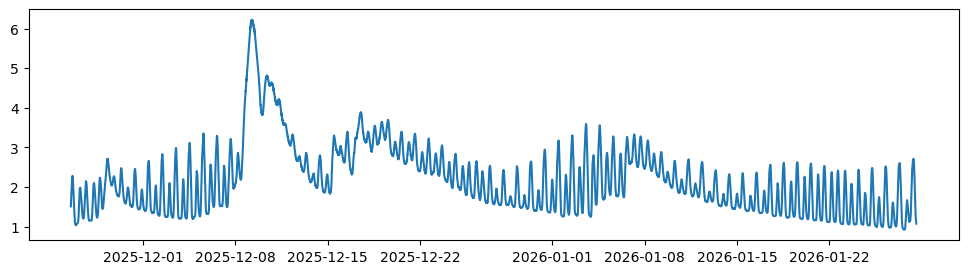

In [167]:
plt.figure(figsize=(12,3))
plt.plot(wr08_dt_trim, wr08_twl_trim)

**USGS**

In [170]:
# waterservices.usgs.gov.txt

usgs_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/wriverusgs.txt"
usgs_df = pd.read_csv(usgs_file, sep='\t', skiprows=list(range(26)) + [27], header=0)

usgs_df["gage h (m)"] = usgs_df["150545_00065"] * 0.3048

usgs_dt = usgs_df["datetime"]
usgs_twl = usgs_df["gage h (m)"]


usgs_df.head()

,agency_cd,site_no,datetime,tz_cd,150545_00065,150545_00065_cd,gage h (m)
0,USGS,12013500,2025-10-31 23:00,PDT,4.31,P,1.313688
1,USGS,12013500,2025-10-31 23:15,PDT,4.33,P,1.319784
2,USGS,12013500,2025-10-31 23:30,PDT,4.36,P,1.328928
3,USGS,12013500,2025-10-31 23:45,PDT,4.38,P,1.335024
4,USGS,12013500,2025-11-01 00:00,PDT,4.41,P,1.344168


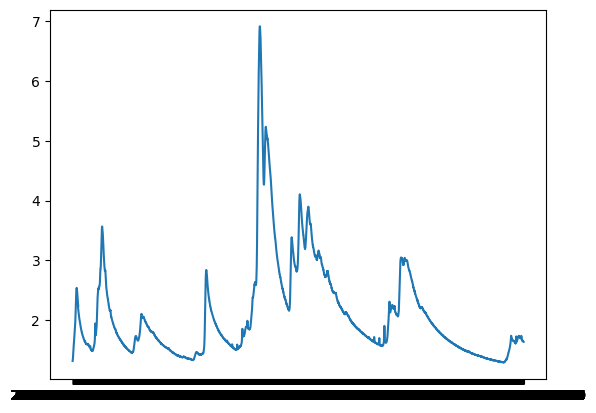

In [172]:
plt.plot(usgs_dt, usgs_twl)

## Timeseries Plot

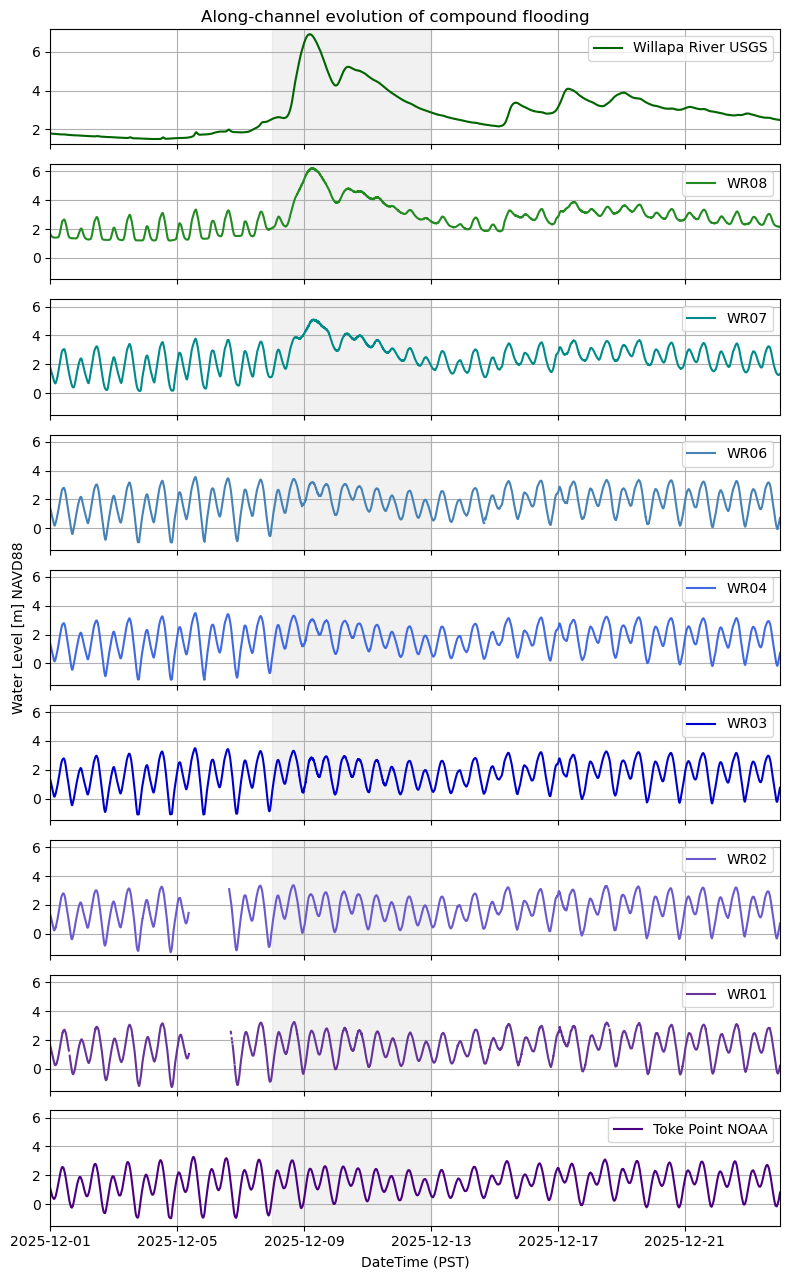

In [174]:
fig, ax = plt.subplots(9, 1, figsize=(8, 13), sharex=True)

# Define date range
plot_start = pd.to_datetime('2025-12-01')
plot_end = pd.to_datetime('2025-12-24')

# Convert to datetime and create masks for filtering
usgs_dt = pd.to_datetime(usgs_dt, errors='coerce')
usgs_mask = (usgs_dt >= plot_start) & (usgs_dt <= plot_end)

wr08_dt_trim = pd.to_datetime(wr08_dt_trim, errors='coerce')
wr08_mask = (wr08_dt_trim >= plot_start) & (wr08_dt_trim <= plot_end)

wr07_dt_trim = pd.to_datetime(wr07_dt_trim, errors='coerce')
wr07_mask = (wr07_dt_trim >= plot_start) & (wr07_dt_trim <= plot_end)

wr06is_dt_trim = pd.to_datetime(wr06is_dt_trim, errors='coerce')
wr06is_mask = (wr06is_dt_trim >= plot_start) & (wr06is_dt_trim <= plot_end)
wr06ctd_dt_trim = pd.to_datetime(wr06ctd_dt_trim, errors='coerce')
wr06ctd_mask = (wr06ctd_dt_trim >= plot_start) & (wr06ctd_dt_trim <= plot_end)

wr04_dt = pd.to_datetime(wr04_dt, errors='coerce')
wr04_mask = (wr04_dt >= plot_start) & (wr04_dt <= plot_end)

wr03_dt = pd.to_datetime(wr03_dt, errors='coerce')
wr03_mask = (wr03_dt >= plot_start) & (wr03_dt <= plot_end)

wr02_dt = pd.to_datetime(wr02_dt, errors='coerce')
wr02_mask = (wr02_dt >= plot_start) & (wr02_dt <= plot_end)

wr01_dt = pd.to_datetime(wr01_dt, errors='coerce')
wr01_mask = (wr01_dt >= plot_start) & (wr01_dt <= plot_end)

TP_dt = pd.to_datetime(TP_dt, errors='coerce')
TP_mask = (TP_dt >= plot_start) & (TP_dt <= plot_end)

# Plot each dataset on separate panels with color gradient
ax[0].plot(usgs_dt[usgs_mask], usgs_twl[usgs_mask], color='darkgreen', label='Willapa River USGS')
ax[0].legend(loc='upper right')
ax[0].grid()

ax[1].plot(wr08_dt_trim[wr08_mask], wr08_twl_trim[wr08_mask], color='forestgreen', label='WR08')
ax[1].legend(loc='upper right')
ax[1].grid()
ax[1].set_ylim([-1.5, 6.5])

ax[2].plot(wr07_dt_trim[wr07_mask], wr07_twl_trim[wr07_mask], color='darkcyan', label='WR07')
ax[2].legend(loc='upper right')
ax[2].grid()
ax[2].set_ylim([-1.5, 6.5])

# WR06 IS and CTD on same panel with same color
ax[3].plot(wr06is_dt_trim[wr06is_mask], wr06is_twl_trim[wr06is_mask], color='steelblue', label='WR06')
ax[3].plot(wr06ctd_dt_trim[wr06ctd_mask], wr06ctd_twl_trim[wr06ctd_mask], color='steelblue')
ax[3].legend(loc='upper right')
ax[3].grid()
ax[3].set_ylim([-1.5, 6.5])

ax[4].plot(wr04_dt[wr04_mask], wr04_twl[wr04_mask], color='royalblue', label='WR04')
ax[4].set_ylabel('Water Level [m] NAVD88')
ax[4].legend(loc='upper right')
ax[4].grid()
ax[4].set_ylim([-1.5, 6.5])

ax[5].plot(wr03_dt[wr03_mask], wr03_twl[wr03_mask], color='mediumblue', label='WR03')
ax[5].legend(loc='upper right')
ax[5].grid()
ax[5].set_ylim([-1.5, 6.5])

ax[6].plot(wr02_dt[wr02_mask], wr02_twl[wr02_mask], color='slateblue', label='WR02')
ax[6].legend(loc='upper right')
ax[6].grid()
ax[6].set_ylim([-1.5, 6.5])

ax[7].plot(wr01_dt[wr01_mask], wr01_twl[wr01_mask], color='rebeccapurple', label='WR01')
ax[7].legend(loc='upper right')
ax[7].grid()
ax[7].set_ylim([-1.5, 6.5])

ax[8].plot(TP_dt[TP_mask], TP_twl[TP_mask], color='indigo', label='Toke Point NOAA')
ax[8].set_xlabel('DateTime (PST)')
ax[8].legend(loc='upper right')
ax[8].grid()
ax[8].set_ylim([-1.5, 6.5])

# Set x-axis limits for all panels
for i in ax:
    i.set_xlim([plot_start, plot_end])
fig.suptitle("Along-channel evolution of compound flooding")

shade_start = pd.Timestamp('2025-12-08')
shade_end = pd.Timestamp('2025-12-13')

for ax in ax:
    ax.axvspan(shade_start, shade_end, alpha=0.3, color='lightgrey', zorder=0)

fig.tight_layout()
plt.show()

## Along-channel Analysis

**(1) RUN EVERYTHING THROUGH UTIDE AND PLOT FOR SANITY CHECK**

In [179]:
### variable names

usgs_twl
usgs_dt

wr08_twl_trim
wr08_dt_trim 

wr07_twl_trim
wr07_dt_trim 

wr06is_twl_trim
wr06is_dt_trim 
wr06ctd_twl_trim
wr06ctd_dt_trim 
wr06_twl = np.concatenate([wr06ctd_twl_trim, wr06is_twl_trim])
wr06_dt = np.concatenate([wr06ctd_dt_trim, wr06is_dt_trim])

wr04_twl
wr04_dt 

wr03_twl
wr03_dt 

wr02_twl
wr02_dt 

wr01_twl
wr01_dt 

tp_twl = TP_twl
tp_dt = TP_dt;

solve: matrix prep ... solution ... done.
prep/calcs ... done.


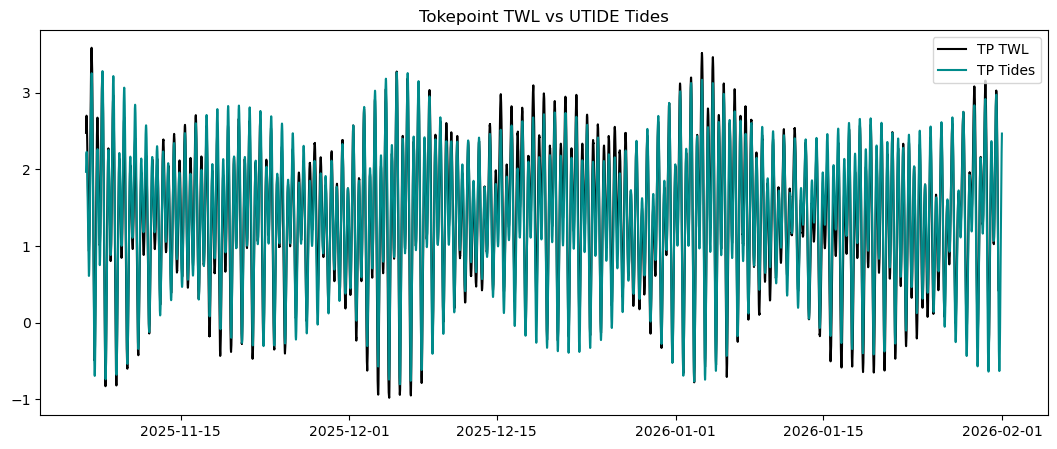

In [181]:
### WR00 (Tokepoint)

tp_lat = 46.707500

coef_tp = solve(tp_dt, tp_twl, lat=tp_lat, method='ols', phase='Greenwich')

tp_utide_summary = pd.DataFrame({'Constituent': coef_tp['name'], 'Amplitude': coef_tp['A'], 'Phase': coef_tp['g']})

recon_tp = reconstruct(tp_dt, coef_tp)

tp_tsl = tp_twl - recon_tp.h

plt.figure(figsize=(13,5))
plt.title('Tokepoint TWL vs UTIDE Tides')
plt.plot(tp_dt, tp_twl, label='TP TWL', color='black')
plt.plot(tp_dt, recon_tp.h, label='TP Tides', color='darkcyan')
plt.legend(loc='upper right');

solve: matrix prep ... solution ... done.
prep/calcs ... done.


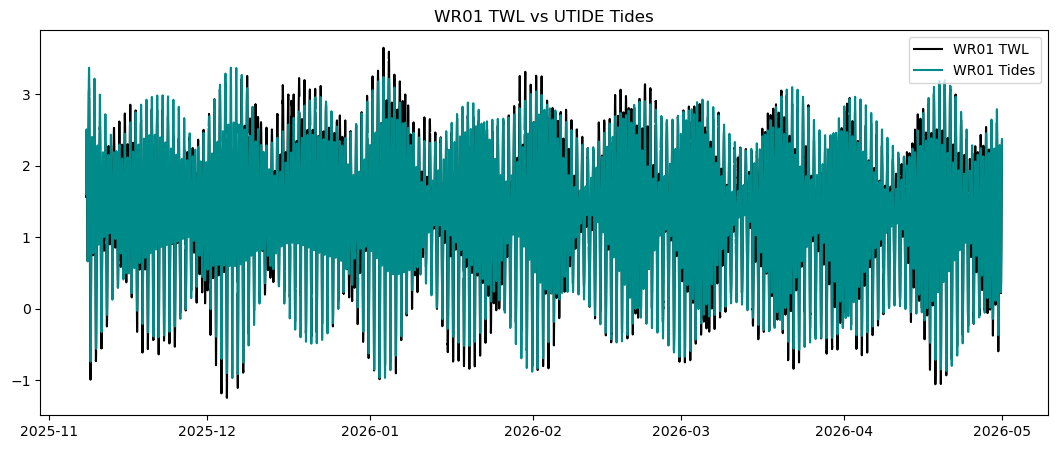

In [183]:
### WR01

wr01_lat = 46.66660923834066

coef_wr01 = solve(wr01_dt, wr01_twl, lat=wr01_lat, method='ols', phase='Greenwich')

wr01_utide_summary = pd.DataFrame({'Constituent': coef_wr01['name'], 'Amplitude': coef_wr01['A'], 'Phase': coef_wr01['g']})

recon_wr01 = reconstruct(wr01_dt, coef_wr01)

wr01_tsl = wr01_twl - recon_wr01.h

plt.figure(figsize=(13,5))
plt.title('WR01 TWL vs UTIDE Tides')
plt.plot(wr01_dt, wr01_twl, label='WR01 TWL', color='black')
plt.plot(wr01_dt, recon_wr01.h, label='WR01 Tides', color='darkcyan')
plt.legend(loc='upper right');

solve: matrix prep ... solution ... done.
prep/calcs ... done.


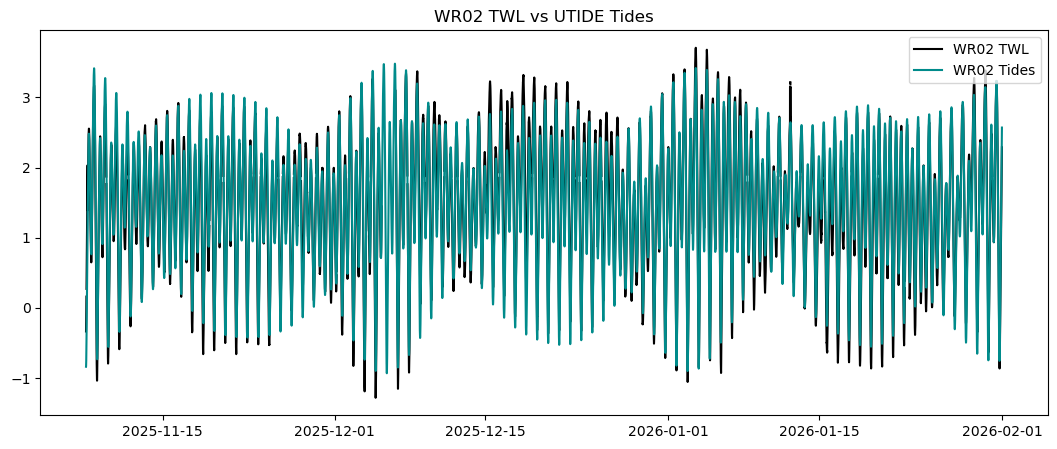

In [184]:
### WR02

wr02_lat = 46.688889

coef_wr02 = solve(wr02_dt, wr02_twl, lat=wr02_lat, method='ols', phase='Greenwich')

wr02_utide_summary = pd.DataFrame({'Constituent': coef_wr02['name'], 'Amplitude': coef_wr02['A'], 'Phase': coef_wr02['g']})

recon_wr02 = reconstruct(wr02_dt, coef_wr02)

wr02_tsl = wr02_twl - recon_wr02.h

plt.figure(figsize=(13,5))
plt.title('WR02 TWL vs UTIDE Tides')
plt.plot(wr02_dt, wr02_twl, label='WR02 TWL', color='black')
plt.plot(wr02_dt, recon_wr02.h, label='WR02 Tides', color='darkcyan')
plt.legend(loc='upper right');

solve: matrix prep ... solution ... done.
prep/calcs ... done.


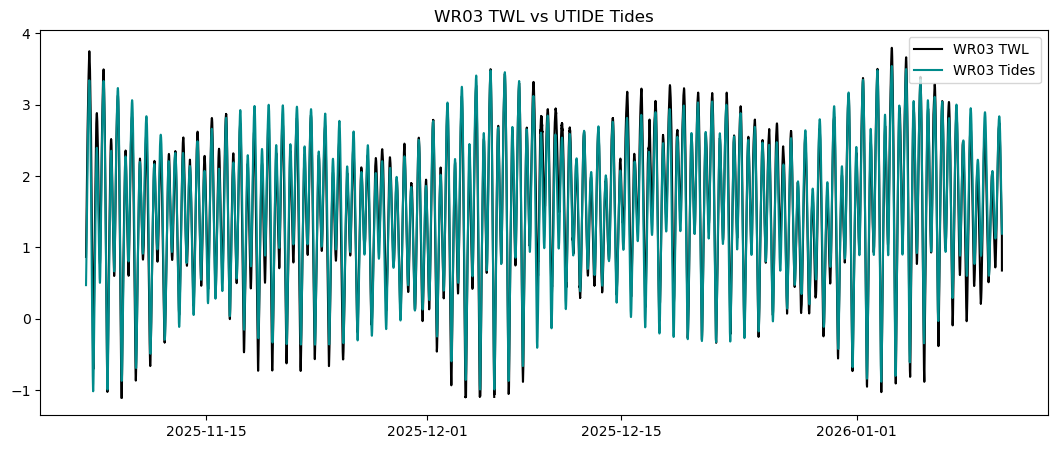

In [185]:
### WR03

wr03_lat = 46.68073986

coef_wr03 = solve( wr03_dt, wr03_twl, lat=wr03_lat, method='ols', phase='Greenwich') 

wr03_utide_summary = pd.DataFrame({'Constituent': coef_wr03['name'], 'Amplitude': coef_wr03['A'], 'Phase': coef_wr03['g']})

recon_wr03 = reconstruct(wr03_dt, coef_wr03)

wr03_tsl = wr03_twl - recon_wr03.h

plt.figure(figsize=(13,5))
plt.title('WR03 TWL vs UTIDE Tides')
plt.plot(wr03_dt, wr03_twl, label='WR03 TWL', color='black')
plt.plot(wr03_dt, recon_wr03.h, label='WR03 Tides', color='darkcyan')
plt.legend(loc='upper right');

solve: matrix prep ... solution ... done.
prep/calcs ... done.


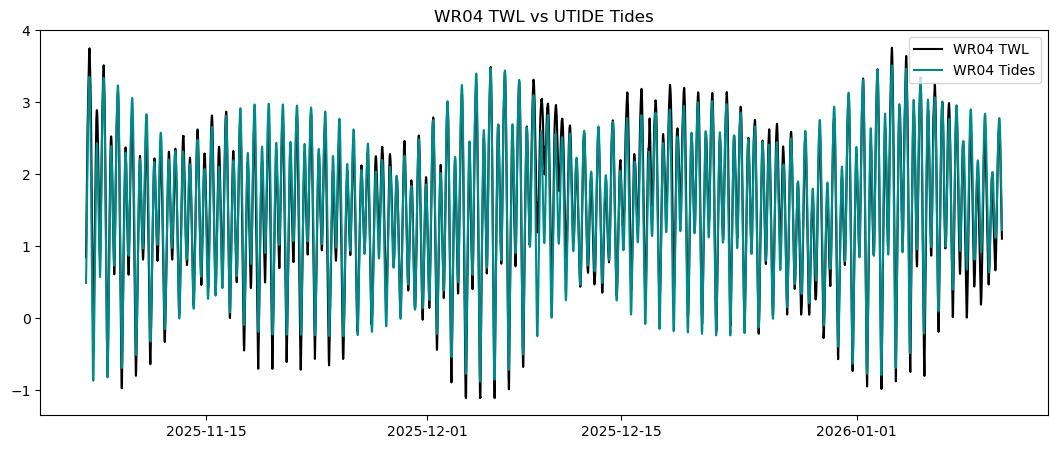

In [186]:
### WR04

wr04_lat = 46.683889

coef_wr04 = solve( wr04_dt, wr04_twl, lat=wr04_lat, method='ols', phase='Greenwich') 

wr04_utide_summary = pd.DataFrame({'Constituent': coef_wr04['name'], 'Amplitude': coef_wr04['A'], 'Phase': coef_wr04['g']})

recon_wr04 = reconstruct(wr04_dt, coef_wr04)

wr04_tsl = wr04_twl - recon_wr04.h

plt.figure(figsize=(13,5))
plt.title('WR04 TWL vs UTIDE Tides')
plt.plot(wr04_dt, wr04_twl, label='WR04 TWL', color='black')
plt.plot(wr04_dt, recon_wr04.h, label='WR04 Tides', color='darkcyan')
plt.legend(loc='upper right');

solve: matrix prep ... solution ... done.
prep/calcs ... done.


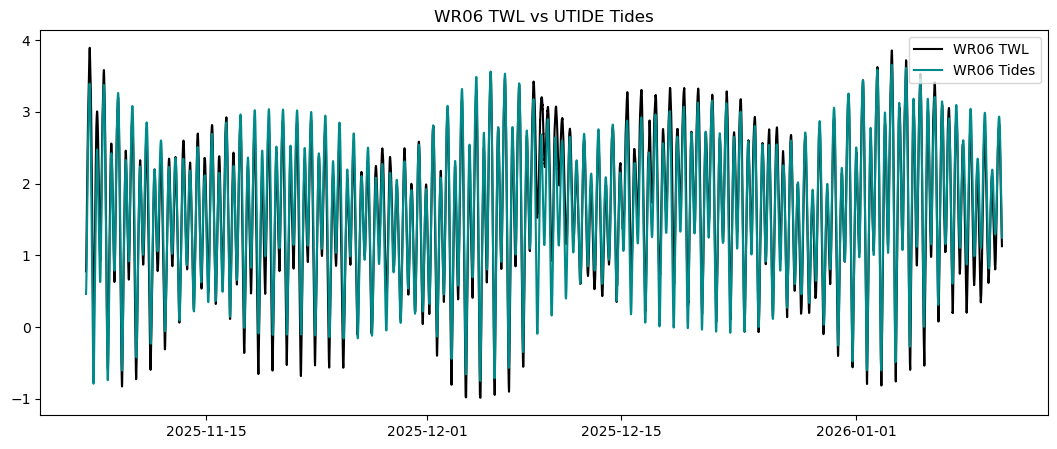

In [191]:
### WR06

wr06_lat = 46.679167

coef_wr06 = solve( wr06_dt, wr06_twl, lat=wr06_lat, method='ols', phase='Greenwich') 

wr06_utide_summary = pd.DataFrame({'Constituent': coef_wr06['name'], 'Amplitude': coef_wr06['A'], 'Phase': coef_wr06['g']})

recon_wr06 = reconstruct(wr06_dt, coef_wr06)

wr06_tsl = wr06_twl - recon_wr06.h

plt.figure(figsize=(13,5))
plt.title('WR06 TWL vs UTIDE Tides')
plt.plot(wr06_dt, wr06_twl, label='WR06 TWL', color='black')
plt.plot(wr06_dt, recon_wr06.h, label='WR06 Tides', color='darkcyan')
plt.legend(loc='upper right');

solve: matrix prep ... solution ... done.
prep/calcs ... done.


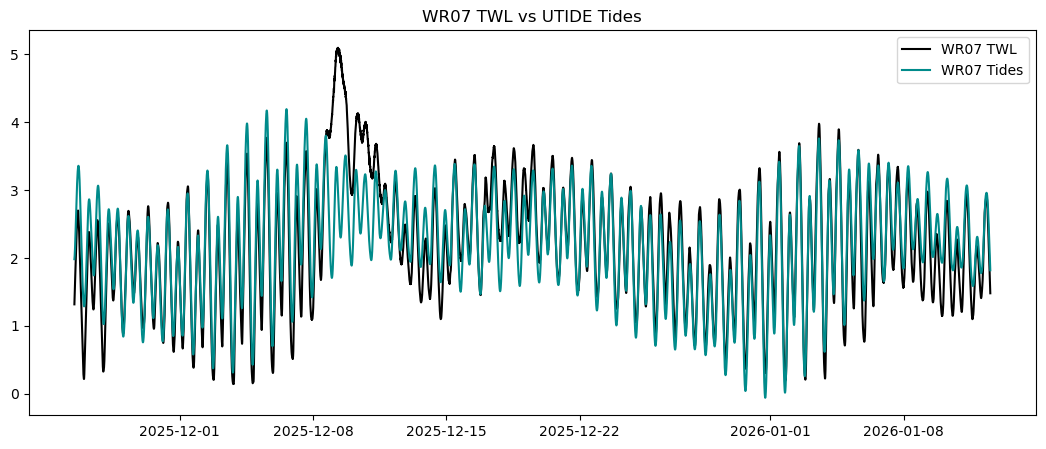

In [192]:
### WR07

wr07_lat = 46.66497456

coef_wr07 = solve( wr07_dt_trim, wr07_twl_trim, lat=wr07_lat, method='ols', phase='Greenwich') 

wr07_utide_summary = pd.DataFrame({'Constituent': coef_wr07['name'], 'Amplitude': coef_wr07['A'], 'Phase': coef_wr07['g']})

recon_wr07 = reconstruct(wr07_dt_trim, coef_wr07)

wr07_tsl = wr07_twl_trim - recon_wr07.h

plt.figure(figsize=(13,5))
plt.title('WR07 TWL vs UTIDE Tides')
plt.plot(wr07_dt_trim, wr07_twl_trim, label='WR07 TWL', color='black')
plt.plot(wr07_dt_trim, recon_wr07.h, label='WR07 Tides', color='darkcyan')
plt.legend(loc='upper right');

**(2) PLOT ALONG-CHANNEL M2 AMPLITUDES**

In [196]:
tp_utide_summary[tp_utide_summary['Constituent'] == 'M2']
tp_m2_amp = tp_utide_summary[tp_utide_summary['Constituent'] == 'M2']['Amplitude'].values[0]
float(tp_m2_amp)

0.9602450289094763

In [198]:
wr01_utide_summary[wr01_utide_summary['Constituent'] == 'M2']
wr01_m2_amp = wr01_utide_summary[wr01_utide_summary['Constituent'] == 'M2']['Amplitude'].values[0]
float(wr01_m2_amp)

1.0677490637017866

In [200]:
wr02_utide_summary[wr02_utide_summary['Constituent'] == 'M2']
wr02_m2_amp = wr02_utide_summary[wr02_utide_summary['Constituent'] == 'M2']['Amplitude'].values[0]
float(wr02_m2_amp)

1.0844985077220397

In [202]:
wr03_utide_summary[wr03_utide_summary['Constituent'] == 'M2']
wr03_m2_amp = wr03_utide_summary[wr03_utide_summary['Constituent'] == 'M2']['Amplitude'].values[0]
float(wr03_m2_amp)

1.0902208263991935

In [204]:
wr04_utide_summary[wr04_utide_summary['Constituent'] == 'M2']
wr04_m2_amp = wr04_utide_summary[wr04_utide_summary['Constituent'] == 'M2']['Amplitude'].values[0]
float(wr04_m2_amp)

1.064263768591022

In [206]:
wr06_utide_summary[wr06_utide_summary['Constituent'] == 'M2']
wr06_m2_amp = wr06_utide_summary[wr06_utide_summary['Constituent'] == 'M2']['Amplitude'].values[0]
float(wr06_m2_amp)

1.054137923062359

In [208]:
wr07_utide_summary[wr07_utide_summary['Constituent'] == 'M2']
wr07_m2_amp = wr07_utide_summary[wr07_utide_summary['Constituent'] == 'M2']['Amplitude'].values[0]
float(wr07_m2_amp)

0.7695860144786995

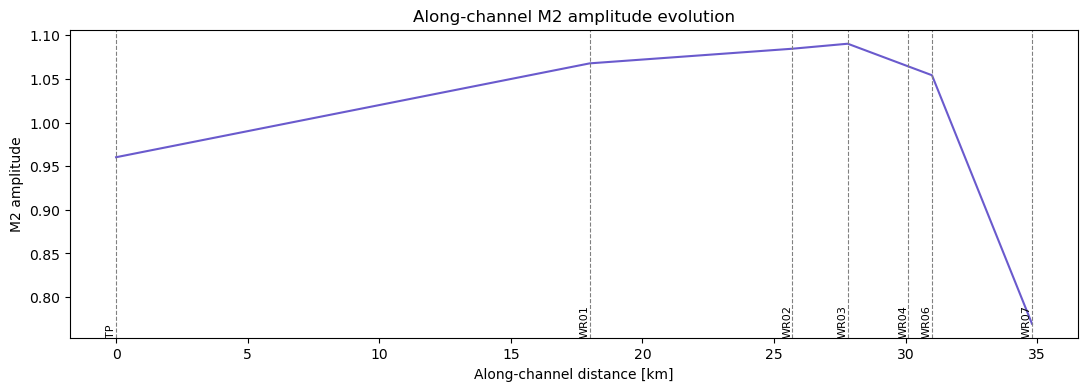

In [210]:
channel_pos_km = [-18, 0, 7.7, 9.8, 12.1, 13, 16.8] # in km

channel_pos_km_adj = []
for i in range(len(channel_pos_km)):
    channel_pos_km_adj.append(channel_pos_km[i] + 18)
    
amplitudes = [tp_m2_amp, wr01_m2_amp, wr02_m2_amp, wr03_m2_amp, wr04_m2_amp, wr06_m2_amp, wr07_m2_amp]

labels = ['TP', 'WR01', 'WR02', 'WR03', 'WR04', 'WR06', 'WR07']

plt.figure(figsize=(13,4))
plt.plot(channel_pos_km_adj, amplitudes, color='slateblue')
plt.title("Along-channel M2 amplitude evolution")
plt.xlabel('Along-channel distance [km]')
plt.ylabel('M2 amplitude')
for x, label in zip(channel_pos_km_adj, labels):
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.8)
    plt.text(x, plt.ylim()[0], label, rotation=90, va='bottom', ha='right', fontsize=8)

In [212]:
for i in range(len(amplitudes)):
    print(amplitudes[i])

0.9602450289094763
1.0677490637017866
1.0844985077220397
1.0902208263991935
1.064263768591022
1.054137923062359
0.7695860144786995


**(2) PLOT ALONG-CHANNEL NLI**

Low frequency pass

In [216]:
# sampling frequency
dt = 5/60 # to match sampling frequency of sensor
fs = 1 / dt

# cutoff frequency
cutoff_period = 35 # hours
cutoff_freq = 1 / cutoff_period

# Nyquist frequency
nyquist = fs / 2

# normalized cutoff frequency
Wn = cutoff_freq / nyquist

# implement butterworth
N = 4 # increase if tidal signals get through
butter_coef1, butter_coef2 = scipy.signal.butter(N, Wn, btype="low")

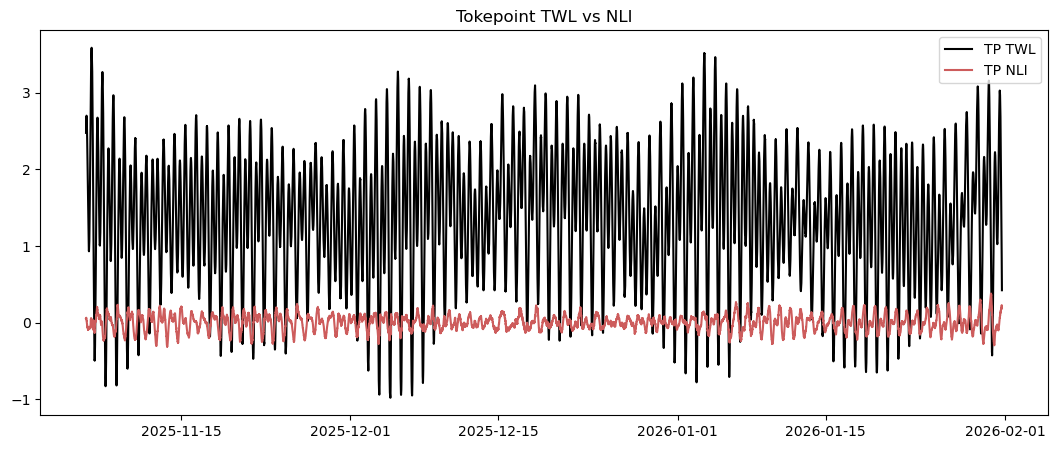

In [218]:
### WR00 (Tokepoint)

# interpolate over NaNs
tp_position = np.arange(len(tp_tsl))
tp_data_exists = ~np.isnan(tp_tsl)
tp_tsl_itp = np.interp(tp_position, tp_position[tp_data_exists], tp_tsl[tp_data_exists])

# apply filter
tp_lfs = scipy.signal.filtfilt(butter_coef1, butter_coef2, tp_tsl_itp)

# obtain NLI signal
tp_nli = tp_tsl - tp_lfs

plt.figure(figsize=(13,5))
plt.title('Tokepoint TWL vs NLI')
plt.plot(tp_dt, tp_twl, label='TP TWL', color='black')
plt.plot(tp_dt, tp_nli, label='TP NLI', color='indianred')
plt.legend(loc='upper right');

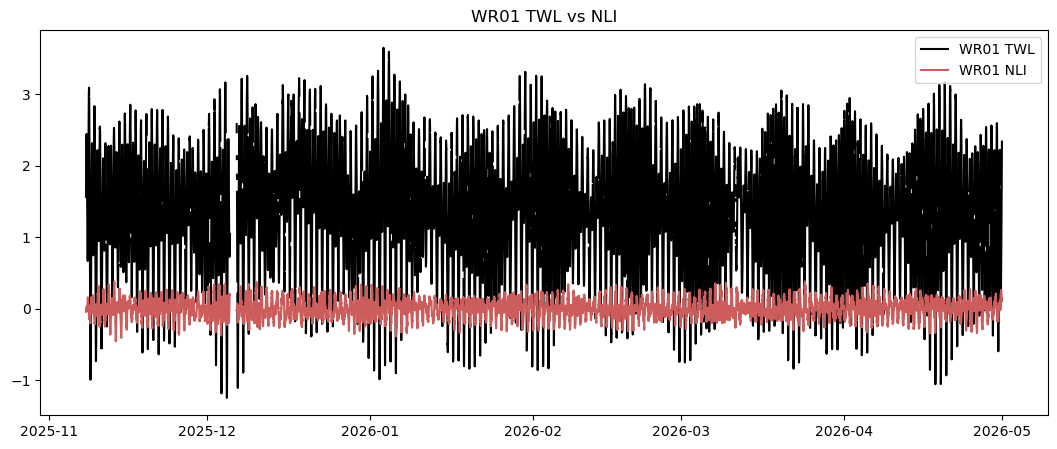

In [219]:
### WR01

# interpolate over NaNs
wr01_position = np.arange(len(wr01_tsl))
wr01_data_exists = ~np.isnan(wr01_tsl)
wr01_tsl_itp = np.interp(wr01_position, wr01_position[wr01_data_exists], wr01_tsl[wr01_data_exists])

# apply filter
wr01_lfs = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr01_tsl_itp)

# obtain NLI signal
wr01_nli = wr01_tsl - wr01_lfs

plt.figure(figsize=(13,5))
plt.title('WR01 TWL vs NLI')
plt.plot(wr01_dt, wr01_twl, label='WR01 TWL', color='black')
plt.plot(wr01_dt, wr01_nli, label='WR01 NLI', color='indianred')
plt.legend(loc='upper right');

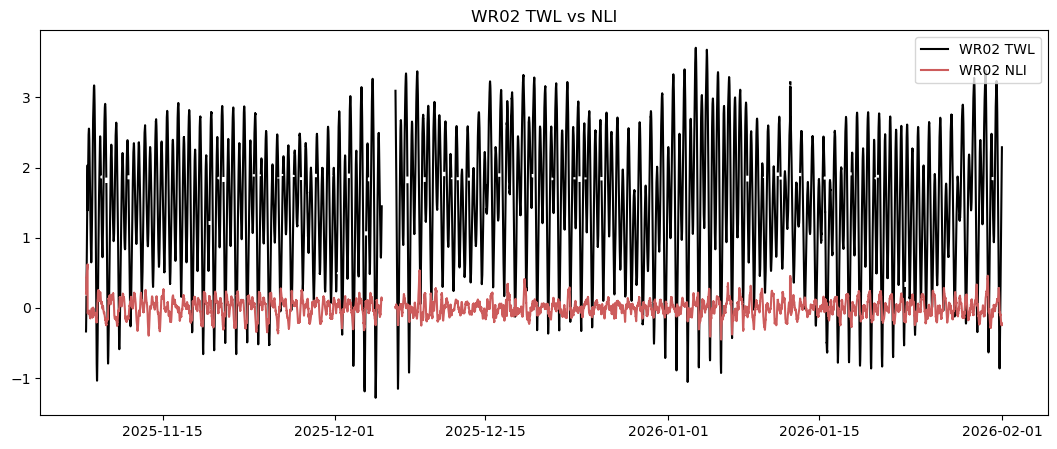

In [221]:
### WR02

# interpolate over NaNs
wr02_position = np.arange(len(wr02_tsl))
wr02_data_exists = ~np.isnan(wr02_tsl)
wr02_tsl_itp = np.interp(wr02_position, wr02_position[wr02_data_exists], wr02_tsl[wr02_data_exists])

# apply filter
wr02_lfs = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr02_tsl_itp)

# obtain NLI signal
wr02_nli = wr02_tsl - wr02_lfs

plt.figure(figsize=(13,5))
plt.title('WR02 TWL vs NLI')
plt.plot(wr02_dt, wr02_twl, label='WR02 TWL', color='black')
plt.plot(wr02_dt, wr02_nli, label='WR02 NLI', color='indianred')
plt.legend(loc='upper right');

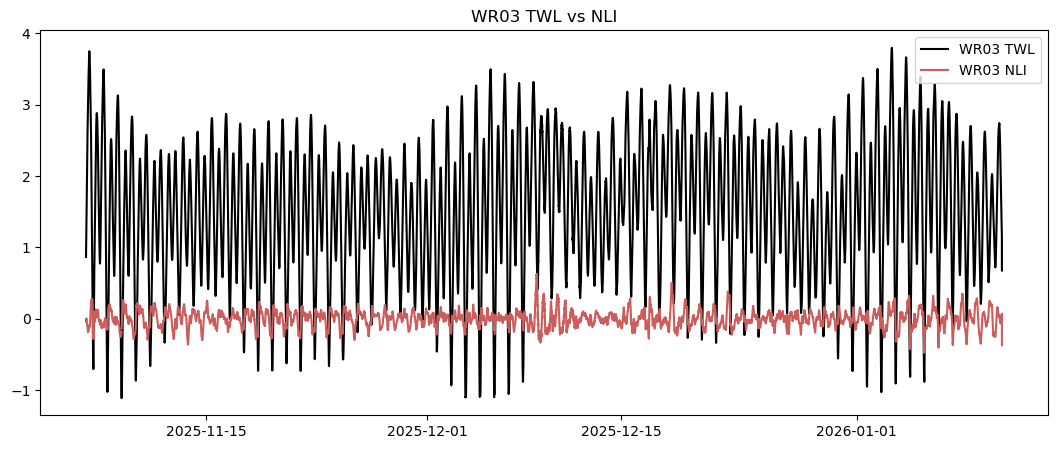

In [223]:
### WR03

# interpolate over NaNs
wr03_position = np.arange(len(wr03_tsl))
wr03_data_exists = ~np.isnan(wr03_tsl)
wr03_tsl_itp = np.interp(wr03_position, wr03_position[wr03_data_exists], wr03_tsl[wr03_data_exists])

# apply filter
wr03_lfs = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr03_tsl_itp)

# obtain NLI signal
wr03_nli = wr03_tsl - wr03_lfs

plt.figure(figsize=(13,5))
plt.title('WR03 TWL vs NLI')
plt.plot(wr03_dt, wr03_twl, label='WR03 TWL', color='black')
plt.plot(wr03_dt, wr03_nli, label='WR03 NLI', color='indianred')
plt.legend(loc='upper right');

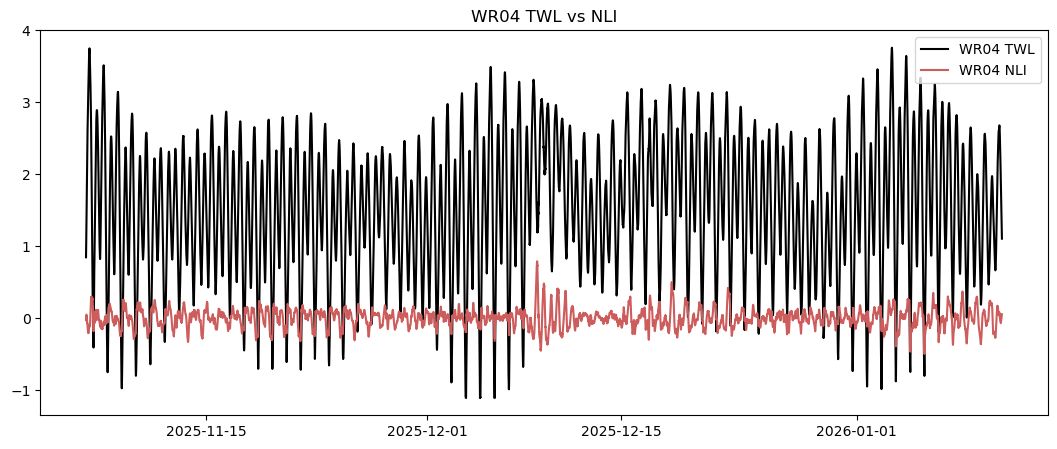

In [226]:
### WR04

# interpolate over NaNs
wr04_position = np.arange(len(wr04_tsl))
wr04_data_exists = ~np.isnan(wr04_tsl)
wr04_tsl_itp = np.interp(wr04_position, wr04_position[wr04_data_exists], wr04_tsl[wr04_data_exists])

# apply filter
wr04_lfs = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr04_tsl_itp)

# obtain NLI signal
wr04_nli = wr04_tsl - wr04_lfs

plt.figure(figsize=(13,5))
plt.title('WR04 TWL vs NLI')
plt.plot(wr04_dt, wr04_twl, label='WR04 TWL', color='black')
plt.plot(wr04_dt, wr04_nli, label='WR04 NLI', color='indianred')
plt.legend(loc='upper right');

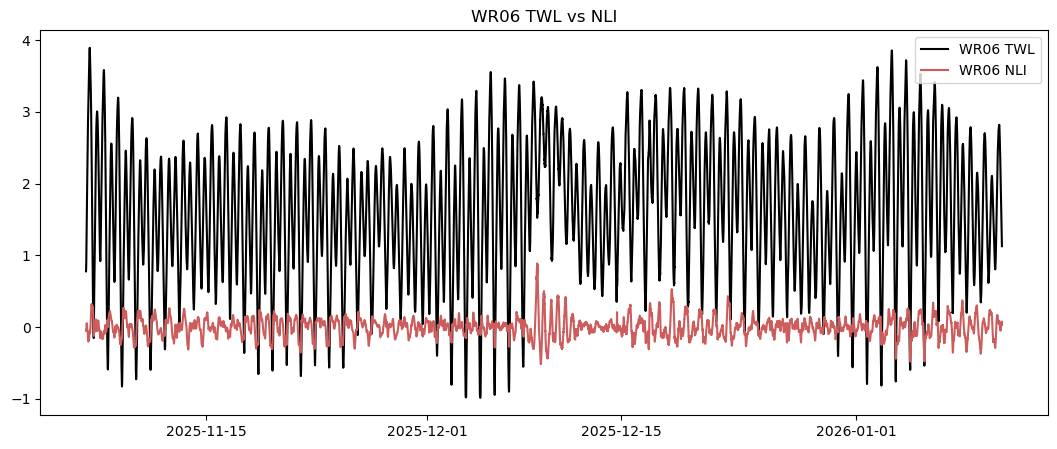

In [228]:
### WR06

# interpolate over NaNs
wr06_position = np.arange(len(wr06_tsl))
wr06_data_exists = ~np.isnan(wr06_tsl)
wr06_tsl_itp = np.interp(wr06_position, wr06_position[wr06_data_exists], wr06_tsl[wr06_data_exists])

# apply filter
wr06_lfs = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr06_tsl_itp)

# obtain NLI signal
wr06_nli = wr06_tsl - wr06_lfs

plt.figure(figsize=(13,5))
plt.title('WR06 TWL vs NLI')
plt.plot(wr06_dt, wr06_twl, label='WR06 TWL', color='black')
plt.plot(wr06_dt, wr06_nli, label='WR06 NLI', color='indianred')
plt.legend(loc='upper right');

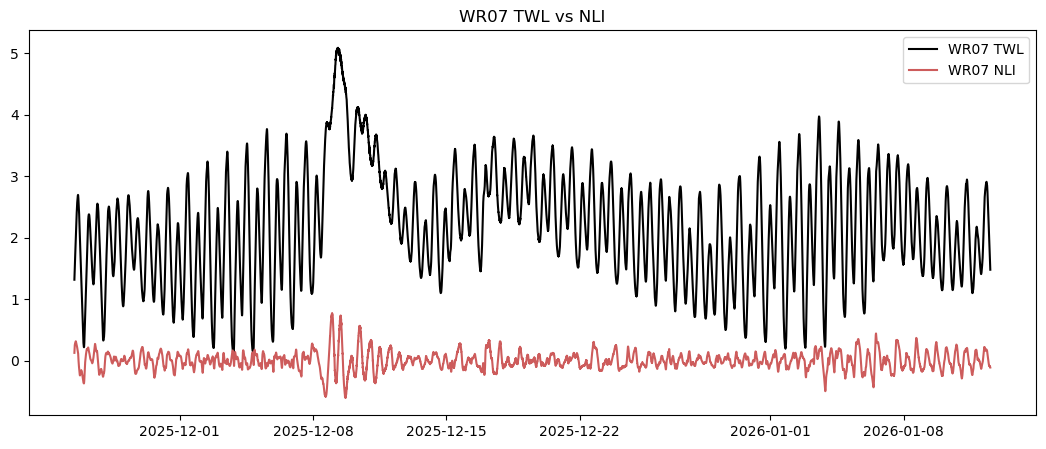

In [230]:
### WR07

# interpolate over NaNs
wr07_position = np.arange(len(wr07_tsl))
wr07_data_exists = ~np.isnan(wr07_tsl)
wr07_tsl_itp = np.interp(wr07_position, wr07_position[wr07_data_exists], wr07_tsl[wr07_data_exists])

# apply filter
wr07_lfs = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr07_tsl_itp)

# obtain NLI signal
wr07_nli = wr07_tsl - wr07_lfs

plt.figure(figsize=(13,5))
plt.title('WR07 TWL vs NLI')
plt.plot(wr07_dt_trim, wr07_twl_trim, label='WR07 TWL', color='black')
plt.plot(wr07_dt_trim, wr07_nli, label='WR07 NLI', color='indianred')
plt.legend(loc='upper right');

In [232]:
wr07_dt[np.argmax(wr07_nli)]

Timestamp('2025-12-08 23:55:08')

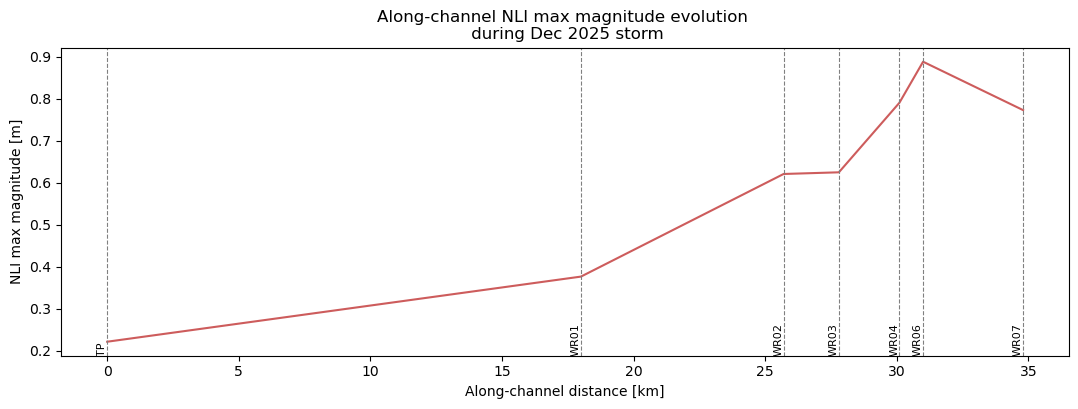

In [234]:
storm_start = pd.Timestamp('2025-12-08')
storm_end = pd.Timestamp('2025-12-13')

tp_nli_max = tp_nli[(tp_dt >= storm_start) & (tp_dt <= storm_end)].max()
wr01_nli_max = wr01_nli[(wr01_dt >= storm_start) & (wr01_dt <= storm_end)].max()
wr02_nli_max = wr02_nli.max()
wr03_nli_max = wr03_nli.max()
wr04_nli_max = wr04_nli.max()
wr06_nli_max = wr06_nli.max()
wr07_nli_max = wr07_nli.max()

nli_max = [tp_nli_max, wr01_nli_max, wr02_nli_max, wr03_nli_max, wr04_nli_max, wr06_nli_max, wr07_nli_max]
labels = ['TP', 'WR01', 'WR02', 'WR03', 'WR04', 'WR06', 'WR07']

plt.figure(figsize=(13,4))
plt.plot(channel_pos_km_adj, nli_max, color='indianred')
plt.title("Along-channel NLI max magnitude evolution \n during Dec 2025 storm")
plt.xlabel('Along-channel distance [km]')
plt.ylabel('NLI max magnitude [m]')
for x, label in zip(channel_pos_km_adj, labels):
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.8)
    plt.text(x, plt.ylim()[0], label, rotation=90, va='bottom', ha='right', fontsize=8)

In [236]:
# fig, ax = plt.subplots(2, 1, figsize=(13,7), constrained_layout=True)
# ax[0].plot(channel_pos_km_adj, amplitudes, color='slateblue', linewidth=2.5)
# ax[0].set_title("Along-channel M2 amplitude evolution", fontsize=16)
# ax[0].set_ylabel('M2 amplitude', fontsize=14)
# ax[0].tick_params(labelsize=13)
# for x, label in zip(channel_pos_km_adj, labels):
#     ax[0].axvline(x=x, color='gray', linestyle='--', linewidth=0.8)
#     ax[0].text(x, ax[0].get_ylim()[0], label, rotation=90, va='bottom', ha='right', fontsize=13)
# ax[1].plot(channel_pos_km_adj, nli_max, color='indianred', linewidth=2.5)
# ax[1].set_title("Along-channel NLI max magnitude evolution \n during Dec 2025 storm", fontsize=16)
# ax[1].set_xlabel('Along-channel distance [km]', fontsize=14)
# ax[1].set_ylabel('NLI max magnitude [m]', fontsize=14)
# ax[1].tick_params(labelsize=13)
# for x, label in zip(channel_pos_km_adj, labels):
#     ax[1].axvline(x=x, color='gray', linestyle='--', linewidth=0.8)
#     ax[1].text(x, ax[1].get_ylim()[0], label, rotation=90, va='bottom', ha='right', fontsize=13)

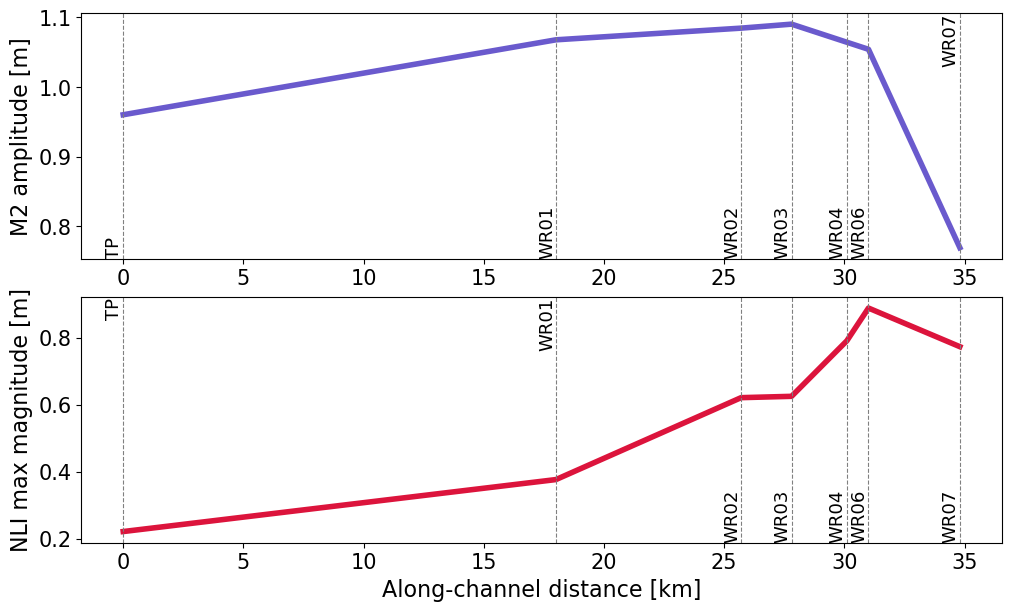

In [263]:
top_labels_ax0 = ['WR07']
top_labels_ax1 = ['TP', 'WR01']

fig, ax = plt.subplots(2, 1, figsize=(10,6), constrained_layout=True)
ax[0].plot(channel_pos_km_adj, amplitudes, color='slateblue', linewidth=4)
# ax[0].set_title("Along-channel M2 amplitude evolution", fontsize=18)
ax[0].set_ylabel('M2 amplitude [m]', fontsize=16)
ax[0].tick_params(labelsize=15)
for x, label in zip(channel_pos_km_adj, labels):
    ax[0].axvline(x=x, color='gray', linestyle='--', linewidth=0.8)
    if label in top_labels_ax0:
        ax[0].text(x, ax[0].get_ylim()[1], label, rotation=90, va='top', ha='right', fontsize=13)
    else:
        ax[0].text(x, ax[0].get_ylim()[0], label, rotation=90, va='bottom', ha='right', fontsize=13)
ax[1].plot(channel_pos_km_adj, nli_max, color='crimson', linewidth=4)
# ax[1].set_title("Along-channel NLI max magnitude evolution \n during Dec 2025 storm", fontsize=18)
ax[1].set_xlabel('Along-channel distance [km]', fontsize=16)
ax[1].set_ylabel('NLI max magnitude [m]', fontsize=16)
ax[1].tick_params(labelsize=15)
for x, label in zip(channel_pos_km_adj, labels):
    ax[1].axvline(x=x, color='gray', linestyle='--', linewidth=0.8)
    if label in top_labels_ax1:
        ax[1].text(x, ax[1].get_ylim()[1], label, rotation=90, va='top', ha='right', fontsize=13)
    else:
        ax[1].text(x, ax[1].get_ylim()[0], label, rotation=90, va='bottom', ha='right', fontsize=13)